# 0) Imports

In [1]:
# install the main library YFinance
!pip install yfinance


[notice] A new release of pip is available: 23.2.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


In [2]:
# rEdit fixes
import sys
!{sys.executable} -m pip install pandas-datareader
!{sys.executable} -m pip install plotly
!{sys.executable} -m pip install matplotlib

# IMPORTS
import numpy as np
import pandas as pd

#Fin Data Sources
import yfinance as yf
import pandas_datareader as pdr

#Data viz
import plotly.graph_objs as go
import plotly.express as px
# Make interactive charts.
# You will use these to see stock price movements visually.

import time
# Lets you add pauses (waits) between downloads.
# Useful so you don't overload the data website.
from datetime import date
# Gets today's date.
# Used to say "get data from start date up to today.


[notice] A new release of pip is available: 23.2.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 23.2.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 23.2.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


# 1) Understanding Data-Driven Decisions data pulls

In [3]:
end = date.today()
print(f'Year = {end.year}; month= {end.month}; day={end.day}')

start = date(year=end.year-70, month=end.month, day=end.day)
print(f'Period for indexes: {start} to {end} ')

# This is your "date calculator." It says: "Get me 70 years of data ending today."

Year = 2026; month= 8; day=20
Period for indexes: 1956-08-20 to 2026-08-20 


## 1.1) GDP

In [4]:
# Real Potential Gross Domestic Product (GDPPOT), Billions of Chained 2012 Dollars, QUARTERLY
# https://fred.stlouisfed.org/series/GDPPOT
gdppot = pdr.DataReader("GDPPOT", "fred", start=start)

# This code downloads data from your start date (70 years ago) up to today.
# Saves it into a variable called gdppot.

# # GDPPOT Comes out quarterly (every 3 months)
# It's about: How much the economy could produce if everything runs smoothly.

# # Why this matters for stock analytics:
# Stocks are connected to the economy.
# If potential GDP is growing → economy is healthy → stocks tend to rise.
# If potential GDP is shrinking → recession risk → stocks may fall.
# You can compare stock prices to this number to see if stocks are over/undervalued relative to the economy.

In [5]:
gdppot['gdppot_us_yoy'] = gdppot.GDPPOT/gdppot.GDPPOT.shift(4)-1
gdppot['gdppot_us_qoq'] = gdppot.GDPPOT/gdppot.GDPPOT.shift(1)-1
gdppot.tail(15)

# # You turned big numbers into useful percentages. This is what analysts actually watch.
# gdppot_us_yoy → How fast the economy is growing vs last year
# gdppot_us_qoq → How fast it grew vs last quarter

# gdppot.GDPPOT.shift(4) → Moves the data 4 rows back (4 quarters = 1 year ago)
# gdppot.GDPPOT/gdppot.GDPPOT.shift(4)-1 → Calculates year-over-year growth (compared to same quarter last year)
# gdppot.GDPPOT.shift(1) → Moves the data 1 row back (1 quarter ago)
# gdppot.GDPPOT/gdppot.GDPPOT.shift(1)-1 → Calculates quarter-over-quarter growth (compared to last quarter)
# gdppot.tail(15) → Shows the last 15 rows so you can see the results

,GDPPOT,gdppot_us_yoy,gdppot_us_qoq
DATE,,,
2023-01-01,22229.482194,0.025405,0.006551
2023-04-01,22377.867950,0.026085,0.006675
2023-07-01,22527.570931,0.026560,0.006690
2023-10-01,22678.156520,0.026867,0.006685
2024-01-01,22828.945411,0.026967,0.006649
2024-04-01,22979.033391,0.026864,0.006574
2024-07-01,23126.896106,0.026604,0.006435
2024-10-01,23271.541687,0.026165,0.006254
2025-01-01,23414.656420,0.025657,0.006150


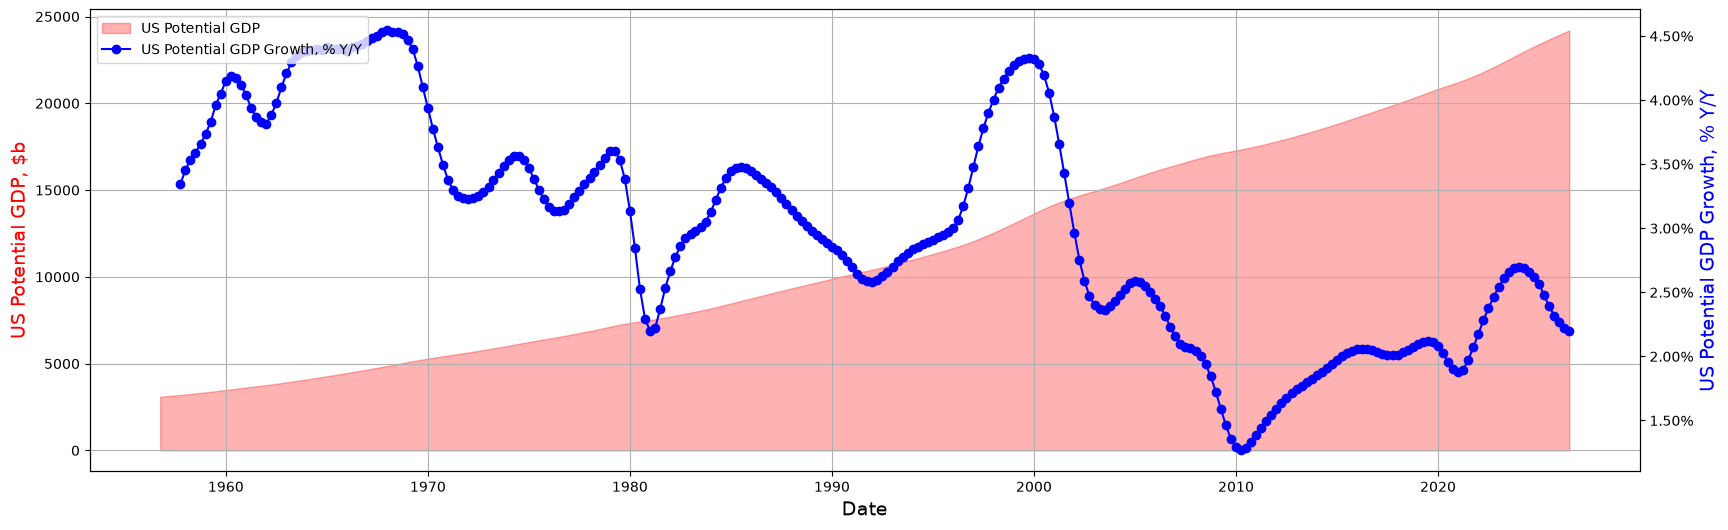

In [6]:
# Visuals GDPPOT
# https://cmdlinetips.com/2019/10/how-to-make-a-plot-with-two-different-y-axis-in-python-with-matplotlib/

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

# v Creates a blank chart, 20 inches wide, 6 inches tall.
# v fig, ax is a tuple variable definition.
fig, ax = plt.subplots(figsize=(20, 6))
# ^ plt.subplot() spits out 2 objects (<Figure size 640x480 with 1 Axes>, <AxesSubplot:>)
# ^ PAY ATTENTION: Default figsize applied is 6.4 inches wide by 4.8 inches tall.
# Therefore we apply figsize=(20, 6) inside plt.subplots(figsize=(20, 6))
# This results in plt.subplots(figsize=(20, 6)) spitting out 2 objects for our tuple definition v
# (<Figure size 2000x600 with 1 Axes>, <AxesSubplot:>)
# fig, ax places these two objects in them. 
# fig is basically the canvas,
# ax is basically the chart.

# v Adds a grid for easier reading to the current active chart.
plt.grid(True)

# Plotting area under US potential GDP curve
# v Fills the area under the GDP line with light red (alpha=0.3 means 30% opacity).
ax.fill_between(gdppot.index, gdppot.GDPPOT, color="red", alpha=0.3, label="US Potential GDP")

# Creating a secondary y-axis for GDP growth percentage
# v Creates a second y-axis on the right side. This lets you plot two different things with different scales.
ax2 = ax.twinx()
# v Formats the right axis as percentages (0.02 becomes 2%).
ax2.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
# v Plots the year-over-year growth as blue dots connected by lines.
ax2.plot(gdppot.gdppot_us_yoy, color="blue", marker="o", label="US Potential GDP Growth, % Y/Y")

# Setting labels and title // Tell you what each axis means.
ax.set_xlabel("Date", fontsize=14)
ax.set_ylabel("US Potential GDP, $b", color="red", fontsize=14)
ax2.set_ylabel("US Potential GDP Growth, % Y/Y", color="blue", fontsize=14)

# Adding legend // Shows which color is which
lines, labels = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines + lines2, labels + labels2, loc='upper left')

plt.show()

## 1.2) Inflation - CPI Core

In [7]:
# # "Core CPI index", MONTHLY
# https://fred.stlouisfed.org/series/CPILFESL
# The "Consumer Price Index for All Urban Consumers: All Items Less Food & Energy"
# is an aggregate of prices paid by urban consumers for a typical basket of goods, excluding food and energy.
# This measurement, known as "Core CPI," is widely used by economists because food and energy have very volatile prices.
cpilfesl = pdr.DataReader("CPILFESL", "fred", start=start)

In [8]:
cpilfesl['cpi_core_yoy'] = cpilfesl.CPILFESL/cpilfesl.CPILFESL.shift(12)-1
cpilfesl['cpi_core_mom'] = cpilfesl.CPILFESL/cpilfesl.CPILFESL.shift(1)-1

cpilfesl.tail(13)

,CPILFESL,cpi_core_yoy,cpi_core_mom
DATE,,,
2025-07-01,328.682,0.030545,0.003125
2025-08-01,329.700,0.031118,0.003097
2025-09-01,330.418,0.030200,0.002178
2025-10-01,NaN,NaN,NaN
2025-11-01,331.043,0.025990,NaN
2025-12-01,331.814,0.026465,0.002329
2026-01-01,332.793,0.025120,0.002950
2026-02-01,333.512,0.024725,0.002161
2026-03-01,334.165,0.026022,0.001958


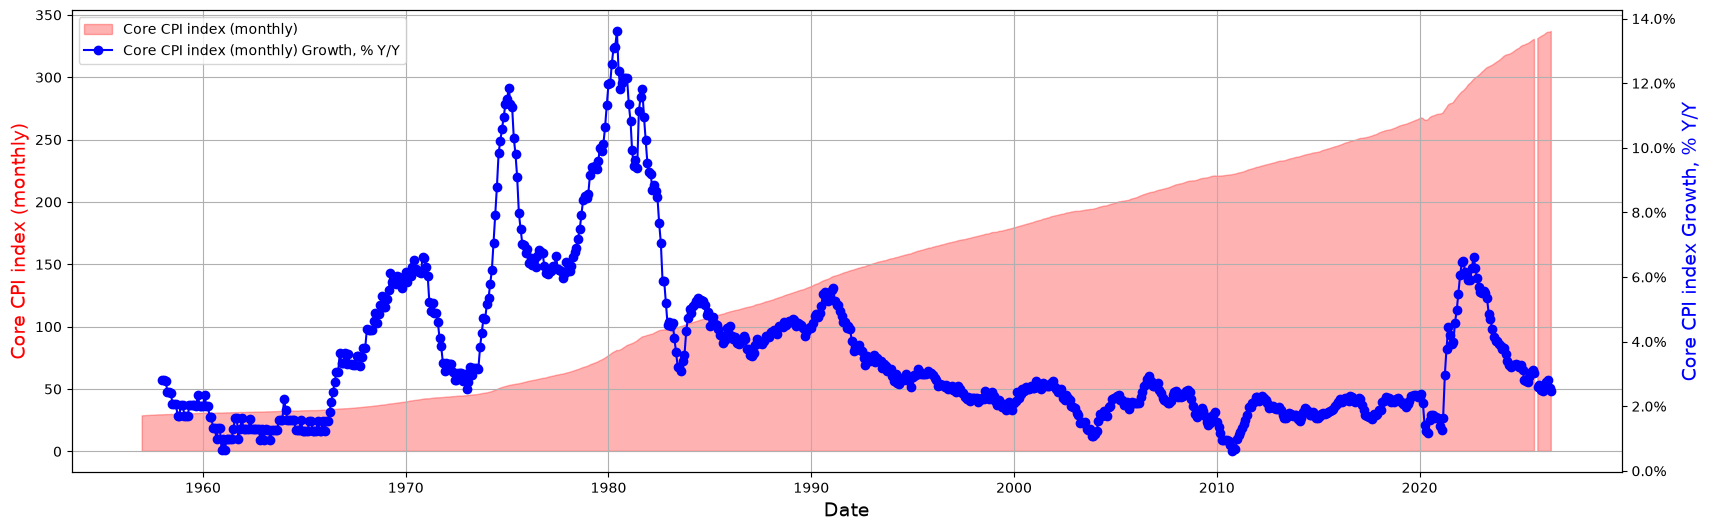

In [9]:
fig, ax = plt.subplots(figsize=(20, 6))
plt.grid(True)

# Plotting area under CPI
ax.fill_between(cpilfesl.index, cpilfesl.CPILFESL, color="red", alpha=0.3, label="Core CPI index (monthly)")

# Creating a secondary y-axis for CPI growth percentage
ax2 = ax.twinx()
ax2.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax2.plot(cpilfesl.cpi_core_yoy, color="blue", marker="o", label="Core CPI index (monthly) Growth, % Y/Y")

# Setting labels and title
ax.set_xlabel("Date", fontsize=14)
ax.set_ylabel("Core CPI index (monthly)", color="red", fontsize=14)
ax2.set_ylabel("Core CPI index Growth, % Y/Y", color="blue", fontsize=14)

# Adding legend
lines, labels = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines + lines2, labels + labels2, loc='upper left')

plt.show()

## 1.3 Interest rates

In [10]:
# Fed rate https://fred.stlouisfed.org/series/FEDFUNDS
fedfunds = pdr.DataReader("FEDFUNDS", "fred", start=start)
fedfunds.tail(10)

,FEDFUNDS
DATE,
2025-10-01,4.09
2025-11-01,3.88
2025-12-01,3.72
2026-01-01,3.64
2026-02-01,3.64
2026-03-01,3.64
2026-04-01,3.64
2026-05-01,3.63
2026-06-01,3.63


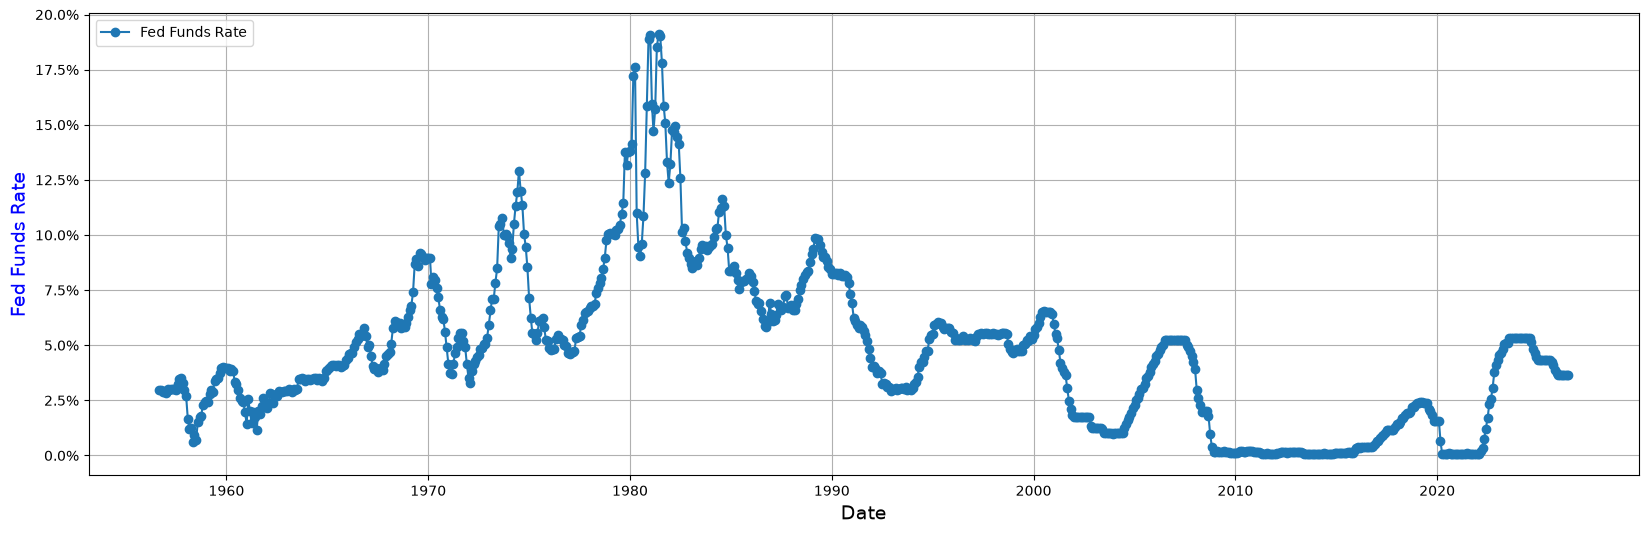

In [11]:
# Fed Funds
fig, ax = plt.subplots(figsize=(20, 6))
plt.grid(True)

# Plotting area under US potential GDP curve
# ax.fill_between(fedfunds.index, fedfunds.FEDFUNDS, color="red", alpha=0.3, label="Core CPI index (monthly)")

# # Creating a secondary y-axis for GDP growth percentage
# ax2 = ax.twinx()
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.plot(fedfunds.index, fedfunds.FEDFUNDS/100, marker="o", label="Fed Funds Rate")

# Setting labels and title
ax.set_xlabel("Date", fontsize=14)
ax.set_ylabel("Fed Funds Rate", color="blue", fontsize=14)

# Adding legend
lines, labels = ax.get_legend_handles_labels()
ax.legend(lines, labels, loc='upper left')

plt.show()

In [12]:
# https://fred.stlouisfed.org/series/DGS1
dgs1 = pdr.DataReader("DGS1", "fred", start=start)
dgs1.tail()

,DGS1
DATE,
2026-08-12,4.00
2026-08-13,3.97
2026-08-14,3.98
2026-08-17,4.00
2026-08-18,3.99


Other rates for US Treasury: https://fred.stlouisfed.org/categories/115  
* https://fred.stlouisfed.org/series/DGS2
* https://fred.stlouisfed.org/series/DGS3
* https://fred.stlouisfed.org/series/DGS5
* https://fred.stlouisfed.org/series/DGS10
...

In [13]:
# https://fred.stlouisfed.org/series/DGS5
dgs5 = pdr.DataReader("DGS5", "fred", start=start)
dgs5.tail()

,DGS5
DATE,
2026-08-12,4.38
2026-08-13,4.32
2026-08-14,4.36
2026-08-17,4.38
2026-08-18,4.37


## 1.4 SNP500

In [14]:
# Other indexes: https://stooq.com/t/

# SPX= S&P500
# spx_index = pdr.get_data_stooq('^SPX', start, end)
# spx_index.head()

# rEdit fix
spx_index = yf.download('^GSPC', start=start, end=end)
spx_index.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,^GSPC,^GSPC,^GSPC,^GSPC,^GSPC
Date,,,,,
1956-08-20,48.250000,48.250000,48.250000,48.250000,1770000
1956-08-21,47.889999,47.889999,47.889999,47.889999,2440000
1956-08-22,47.419998,47.419998,47.419998,47.419998,1570000
1956-08-23,48.000000,48.000000,48.000000,48.000000,1590000
1956-08-24,47.950001,47.950001,47.950001,47.950001,1530000


In [15]:
# 252 trading days a year
  # REVERSE ORDER OF THE DATA!!!
spx_index['spx_dod'] = (spx_index.Close/spx_index.Close.shift(-1)-1)
spx_index['spx_qoq'] = (spx_index.Close/spx_index.Close.shift(-63)-1)
spx_index['spx_yoy'] = (spx_index.Close/spx_index.Close.shift(-252)-1)

In [16]:
spx_index.head()

Price,Close,High,Low,Open,Volume,spx_dod,spx_qoq,spx_yoy
Ticker,^GSPC,^GSPC,^GSPC,^GSPC,^GSPC,,,
Date,,,,,,,,
1956-08-20,48.250000,48.250000,48.250000,48.250000,1770000,0.007517,0.065357,0.060673
1956-08-21,47.889999,47.889999,47.889999,47.889999,2440000,0.009911,0.066830,0.060452
1956-08-22,47.419998,47.419998,47.419998,47.419998,1570000,-0.012083,0.061563,0.065379
1956-08-23,48.000000,48.000000,48.000000,48.000000,1590000,0.001043,0.063358,0.093643
1956-08-24,47.950001,47.950001,47.950001,47.950001,1530000,0.006085,0.068643,0.074871


In [17]:
spx_truncated = spx_index[spx_index.index>='1990-01-01']

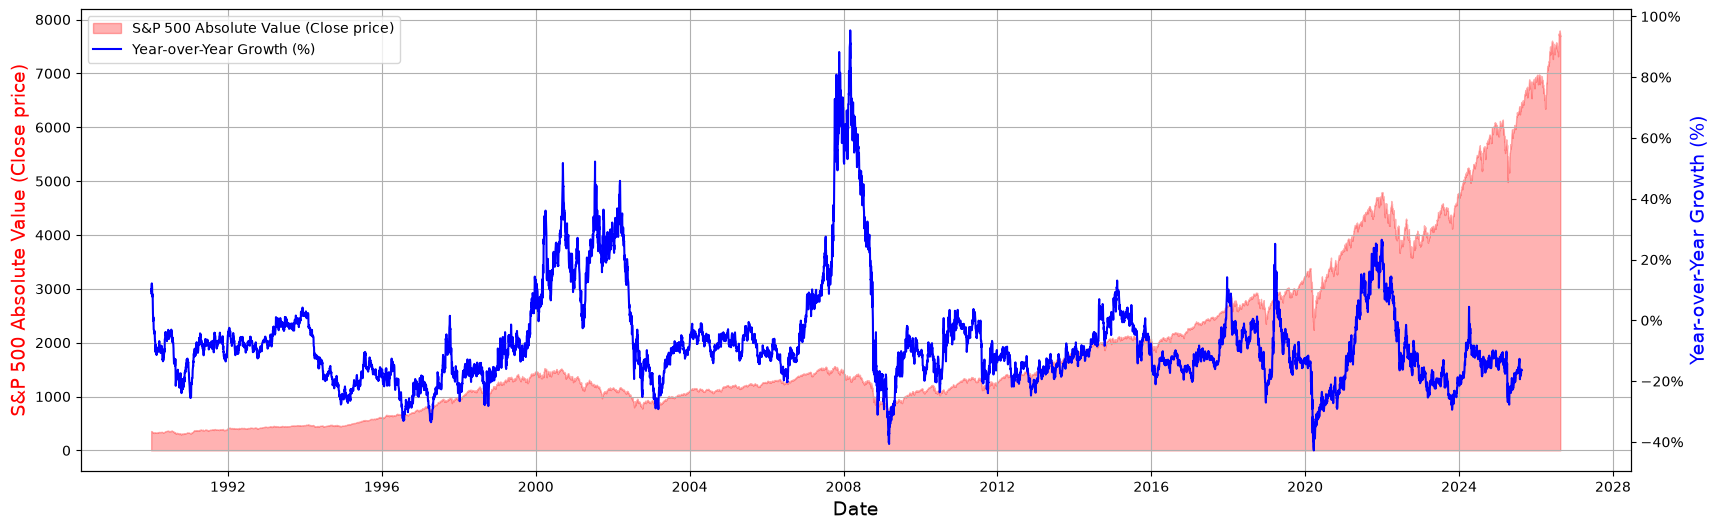

In [18]:
# S&P500 abs. vs. relative growth
fig, ax = plt.subplots(figsize=(20, 6))
plt.grid(True)

# Make sure Close is a 1D Series
close_prices = spx_truncated['Close'].squeeze()

# Plotting area under S&P 500
ax.fill_between(spx_truncated.index, close_prices, color="red", alpha=0.3, label="S&P 500 Absolute Value (Close price)")

# Creating a secondary y-axis for growth percentage
ax2 = ax.twinx()
ax2.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax2.plot(spx_truncated.spx_yoy,
         color="blue",
         label="Year-over-Year Growth (%)")

# Setting labels and title
ax.set_xlabel("Date", fontsize=14)
ax.set_ylabel("S&P 500 Absolute Value (Close price)", color="red", fontsize=14)
ax2.set_ylabel("Year-over-Year Growth (%)", color="blue", fontsize=14)

# Adding legend
lines, labels = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines + lines2, labels + labels2, loc='upper left')

plt.show()

# 2) Data Sources for Stocks

## 2.1 OHLCV data daily - INDEXES

In [19]:
# INDEXES from Yahoo Finance
# DAX index (XETRA - XETRA Delayed Price. Currency in EUR)
# WEB: https://finance.yahoo.com/quote/%5EGDAXI
# Option 1: dax_daily = yf.download(tickers = ["^GDAXI"],
#                      period = "max",
#                      interval = "1d")

# Option 2 (preferred):
# Download data with Adj Close for more accurate price reflections
ticker_obj = yf.Ticker("^GDAXI")
dax_daily = ticker_obj.history(start = start)

In [20]:
dax_daily.tail()

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2026-08-13 00:00:00+02:00,26437.349609,26489.779297,26285.230469,26299.740234,45248900,0.0,0.0
2026-08-14 00:00:00+02:00,26445.990234,26541.339844,26404.949219,26440.310547,52369300,0.0,0.0
2026-08-17 00:00:00+02:00,26490.300781,26493.500000,26338.609375,26338.609375,38194400,0.0,0.0
2026-08-18 00:00:00+02:00,26280.859375,26292.949219,26119.539062,26128.359375,47429900,0.0,0.0
2026-08-19 00:00:00+02:00,26146.119141,26187.820312,26063.369141,26091.330078,46190700,0.0,0.0


In [21]:
# normally 252 trading days
# v Adds a column with the price from 252 trading days ago.
dax_daily['adj_close_last_year'] = dax_daily['Close'].shift(252)
# v Adds a column with the percentage change from 1 year ago.
dax_daily['yoy_growth'] = dax_daily['Close'] / dax_daily['adj_close_last_year'] -1

In [22]:
dax_daily

,Open,High,Low,Close,Volume,Dividends,Stock Splits,adj_close_last_year,yoy_growth
Date,,,,,,,,,
1987-12-30 00:00:00+01:00,1005.190002,1005.190002,1005.190002,1005.190002,0,0.0,0.0,NaN,NaN
1988-01-04 00:00:00+01:00,956.489990,956.489990,956.489990,956.489990,0,0.0,0.0,NaN,NaN
1988-01-05 00:00:00+01:00,996.099976,996.099976,996.099976,996.099976,0,0.0,0.0,NaN,NaN
1988-01-06 00:00:00+01:00,1006.010010,1006.010010,1006.010010,1006.010010,0,0.0,0.0,NaN,NaN
1988-01-07 00:00:00+01:00,1014.469971,1014.469971,1014.469971,1014.469971,0,0.0,0.0,NaN,NaN
...,...,...,...,...,...,...,...,...,...
2026-08-13 00:00:00+02:00,26437.349609,26489.779297,26285.230469,26299.740234,45248900,0.0,0.0,24377.500000,0.078853
2026-08-14 00:00:00+02:00,26445.990234,26541.339844,26404.949219,26440.310547,52369300,0.0,0.0,24359.300781,0.085430
2026-08-17 00:00:00+02:00,26490.300781,26493.500000,26338.609375,26338.609375,38194400,0.0,0.0,24314.769531,0.083235


<Axes: xlabel='Date'>

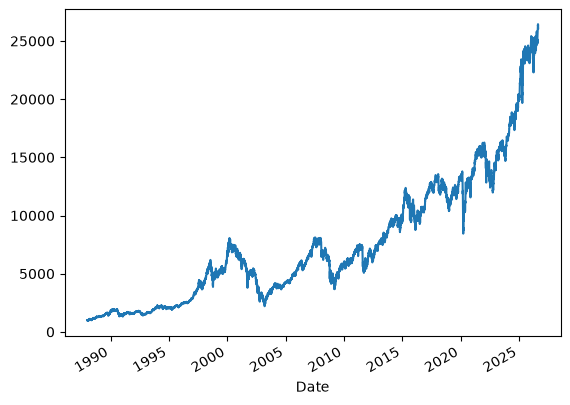

In [23]:
dax_daily['Close'].plot.line()

In [24]:
# delayed 15 min : https://finance.yahoo.com/quote/%5ESPX/
# S&P 500 INDEX : Chicago Options - Chicago Options Delayed Price. Currency in USD
ticker_obj = yf.Ticker("^SPX")
snp500_daily = ticker_obj.history(start = start, interval = "1d")

# old version:
# snp500_daily = yf.download(tickers = "^SPX",
#                      period = "max",
#                      interval = "1d")

In [25]:
snp500_daily.tail()

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2026-08-13 00:00:00-04:00,7763.180176,7816.700195,7763.180176,7798.990234,4833230000,0.0,0.0
2026-08-14 00:00:00-04:00,7806.600098,7810.009766,7776.310059,7785.759766,4159900000,0.0,0.0
2026-08-17 00:00:00-04:00,7790.680176,7790.680176,7744.879883,7745.060059,4452630000,0.0,0.0
2026-08-18 00:00:00-04:00,7700.040039,7713.950195,7688.629883,7691.759766,4602700000,0.0,0.0
2026-08-19 00:00:00-04:00,7716.740234,7743.930176,7700.069824,7707.979980,3041364386,0.0,0.0


In [26]:
# https://finance.yahoo.com/quote/%5EGSPC/
# SNP - SNP Real Time Price. Currency in USD
# https://www.investopedia.com/insights/introduction-to-stock-market-indices/

ticker_obj = yf.Ticker("^GSPC")
snp500_daily_non_delayed = ticker_obj.history(start = start, interval = "1d")

# old version:
# snp500_daily_non_delayed = yf.download(tickers = "^GSPC",
#                      period = "max",
#                      interval = "1d")

In [27]:
snp500_daily_non_delayed.tail()

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2026-08-13 00:00:00-04:00,7763.180176,7816.700195,7763.180176,7798.990234,4833230000,0.0,0.0
2026-08-14 00:00:00-04:00,7806.600098,7810.009766,7776.310059,7785.759766,4159900000,0.0,0.0
2026-08-17 00:00:00-04:00,7790.680176,7790.680176,7744.879883,7745.060059,4452630000,0.0,0.0
2026-08-18 00:00:00-04:00,7700.040039,7713.950195,7688.629883,7691.759766,4602700000,0.0,0.0
2026-08-19 00:00:00-04:00,7716.740234,7743.930176,7700.069824,7707.979980,2981221000,0.0,0.0


In [28]:
# Dow Jones Industrial Average: https://finance.yahoo.com/quote/%5EDJI?.tsrc=fin-srch

ticker_obj = yf.Ticker("^DJI")
dji_daily = ticker_obj.history(start = start, interval = "1d")

# dji_daily = yf.download(tickers = "^DJI",
#                      period = "max",
#                      interval = "1d")

## 2.2 OHLCV data daily - ETFs

In [29]:
# https://finance.yahoo.com/quote/VOO?.tsrc=fin-srch
# V Voo is an ETF that tracks the S&P 500 index. This downloads daily price data for the VOO ETF.

ticker_obj = yf.Ticker("VOO")
voo_etf = ticker_obj.history(start = start, interval = "1d")

# voo_etf = yf.download(tickers = "VOO",
#                      period = "max",
#                      interval = "1d")


In [30]:
voo_etf.tail()

,Open,High,Low,Close,Volume,Dividends,Stock Splits,Capital Gains
Date,,,,,,,,
2026-08-13 00:00:00-04:00,712.299988,716.390015,711.609985,714.950012,4590000,0.0,0.0,0.0
2026-08-14 00:00:00-04:00,715.630005,715.890015,712.799988,713.609985,4236400,0.0,0.0,0.0
2026-08-17 00:00:00-04:00,713.500000,714.049988,710.099976,710.270020,5745000,0.0,0.0,0.0
2026-08-18 00:00:00-04:00,706.609985,707.349976,704.960022,705.400024,5278600,0.0,0.0,0.0
2026-08-19 00:00:00-04:00,708.190002,710.085022,706.094971,706.909973,6980082,0.0,0.0,0.0


In [31]:
# ETFs
# WisdomTree India Earnings Fund (EPI)
# NYSEArca - Nasdaq Real Time Price. Currency in USD
# WEB: https://finance.yahoo.com/quote/EPI/history?p=EPI

# Why EPI?: 
# It gives you exposure to the Indian stock market through a single ticker, 
# instead of downloading individual Indian stocks.

ticker_obj = yf.Ticker("EPI")
epi_etf_daily = ticker_obj.history(start = start, interval = "1d")

# epi_etf_daily = yf.download(tickers = "EPI",
#                      period = "max",
#                      interval = "1d")

In [32]:
epi_etf_daily.head()
print(epi_etf_daily.shape)
# ^ That means your EPI data has 4,650 rows and 8 columns.

(4650, 8)


In [ ]:
# find dividends impact on Close vs. Adj.Close
# This finds and shows the last 5 dividend payment dates for EPI.
epi_etf_daily[epi_etf_daily.Dividends>0].tail()

,Open,High,Low,Close,Volume,Dividends,Stock Splits,Capital Gains
Date,,,,,,,,
2021-12-27 00:00:00-05:00,33.577714,33.801816,33.577714,33.764465,379100,0.192,0.0,0.0
2022-03-25 00:00:00-04:00,33.563275,33.666313,33.432129,33.666313,584400,0.115,0.0,0.0
2022-06-24 00:00:00-04:00,29.420327,29.778748,29.370547,29.768791,387900,1.845,0.0,0.0
2023-06-26 00:00:00-04:00,34.020314,34.070182,33.960471,33.990395,634600,0.060,0.0,0.0
2024-12-26 00:00:00-05:00,45.840000,45.840000,45.700001,45.820000,685600,0.121,0.0,0.0


In [ ]:
epi_etf_daily[(epi_etf_daily.index >='2024-12-23') & (epi_etf_daily.index <='2024-12-28')]
# ^ This code shows you EPI data for a specific date range: December 23 to December 28, 2024.

,Open,High,Low,Close,Volume,Dividends,Stock Splits,Capital Gains
Date,,,,,,,,
2024-12-23 00:00:00-05:00,45.609761,45.879052,45.609761,45.869080,630400,0.000,0.0,0.0
2024-12-24 00:00:00-05:00,45.719475,45.928922,45.709503,45.899002,277100,0.000,0.0,0.0
2024-12-26 00:00:00-05:00,45.840000,45.840000,45.700001,45.820000,685600,0.121,0.0,0.0
2024-12-27 00:00:00-05:00,45.570000,45.650002,45.500000,45.639999,774900,0.000,0.0,0.0


In [ ]:
# find dividends - diff for Close vs. Adj Close
# Open/Close for 06-25 diff is close to divs = 1.845 (~1.58 for Open and 1.3 for Close)
# HELP: https://help.yahoo.com/kb/SLN28256.html#:~:text=Adjusted%20close%20is%20the%20closing,Security%20Prices%20(CRSP)%20standards.
epi_etf_daily[(epi_etf_daily.index >='2024-12-23') & (epi_etf_daily.index <='2024-12-28')]

# ^ This code helps you see when dividends are paid by comparing Close and Adj Close.
# Why compare Close vs. Adj Close: On a dividend payment day, 
# the stock price drops by the dividend amount. 
# The Close price shows this lower price, 
# but the Adj Close adjusts upward to remove the dividend's effect. 
# Comparing them lets you see exactly when a dividend was paid and how much it was. 
# Without Adj Close, you would just see a price drop and not know if it was a dividend or a market crash. 
# The difference between the two equals the dividend amount.



,Open,High,Low,Close,Volume,Dividends,Stock Splits,Capital Gains
Date,,,,,,,,
2024-12-23 00:00:00-05:00,45.609761,45.879052,45.609761,45.869080,630400,0.000,0.0,0.0
2024-12-24 00:00:00-05:00,45.719475,45.928922,45.709503,45.899002,277100,0.000,0.0,0.0
2024-12-26 00:00:00-05:00,45.840000,45.840000,45.700001,45.820000,685600,0.121,0.0,0.0
2024-12-27 00:00:00-05:00,45.570000,45.650002,45.500000,45.639999,774900,0.000,0.0,0.0


In [ ]:
# Previous option : no Div. dates , same stats
epi_etf_daily2 = yf.download(tickers = "EPI",
                     period = "max",
                     interval = "1d")
# ^ This code downloads EPI data again using a different method.

[*********************100%***********************]  1 of 1 completed


In [37]:
epi_etf_daily2[epi_etf_daily2.index>='2024-12-23'].head()

Price,Close,High,Low,Open,Volume
Ticker,EPI,EPI,EPI,EPI,EPI
Date,,,,,
2024-12-23,45.869080,45.879052,45.609761,45.609761,630400
2024-12-24,45.899002,45.928922,45.709503,45.719475,277100
2024-12-26,45.820000,45.840000,45.700001,45.840000,685600
2024-12-27,45.639999,45.650002,45.500000,45.570000,774900
2024-12-30,45.090000,45.180000,44.980000,45.180000,1442100


<Axes: title={'center': "EPI's etf stock price"}, xlabel='Date'>

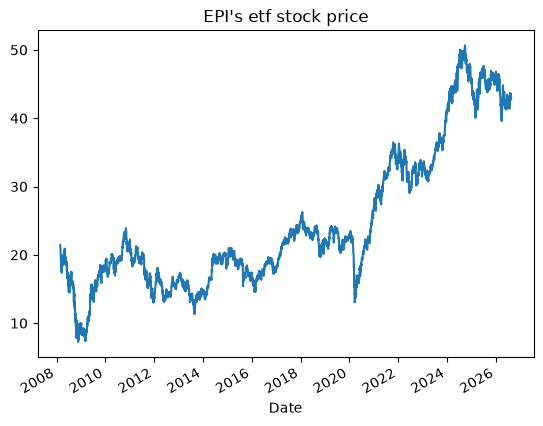

In [ ]:
# About yFinance: https://zoo.cs.yale.edu/classes/cs458/lectures/yfinance.html
# v This code creates a simple line chart of EPI's closing price.
epi_etf_daily['Close'].plot(title="EPI's etf stock price")

In [ ]:
# get actions, incl. dividends - as a dataFrame
# v This code gets a list of all corporate actions for EPI.
epi = yf.Ticker('EPI')
epi.get_actions()

,Dividends
Date,
2008-12-22 00:00:00-05:00,0.091
2009-03-23 00:00:00-04:00,0.007
2009-06-22 00:00:00-04:00,0.002
2009-09-21 00:00:00-04:00,0.045
2009-12-21 00:00:00-05:00,0.006
2010-06-28 00:00:00-04:00,0.065
2010-09-20 00:00:00-04:00,0.065
2010-12-22 00:00:00-05:00,0.013
2011-06-22 00:00:00-04:00,0.062


In [ ]:
# get dividends as Series
epi.get_dividends()

# get_actions() shows dividends and splits together in one table. 
# get_dividends() shows only dividends, without splits. 
# So get_dividends() is cleaner if you only care about cash payments.

Date
2008-12-22 09:30:00-05:00    0.091
2009-03-23 09:30:00-04:00    0.007
2009-06-22 09:30:00-04:00    0.002
2009-09-21 09:30:00-04:00    0.045
2009-12-21 09:30:00-05:00    0.006
2010-06-28 09:30:00-04:00    0.065
2010-09-20 09:30:00-04:00    0.065
2010-12-22 09:30:00-05:00    0.013
2011-06-22 09:30:00-04:00    0.062
2011-09-26 09:30:00-04:00    0.098
2012-03-26 09:30:00-04:00    0.010
2012-06-25 09:30:00-04:00    0.045
2012-09-24 09:30:00-04:00    0.083
2012-12-24 09:30:00-05:00    0.024
2013-06-24 09:30:00-04:00    0.068
2013-09-23 09:30:00-04:00    0.063
2014-03-24 09:30:00-04:00    0.099
2014-06-23 09:30:00-04:00    0.059
2014-09-22 09:30:00-04:00    0.068
2015-03-23 09:30:00-04:00    0.031
2015-06-22 09:30:00-04:00    0.067
2015-09-21 09:30:00-04:00    0.116
2015-12-21 09:30:00-05:00    0.024
2016-03-21 09:30:00-04:00    0.010
2016-06-20 09:30:00-04:00    0.125
2016-09-26 09:30:00-04:00    0.070
2016-12-23 09:30:00-05:00    0.006
2017-03-27 09:30:00-04:00    0.075
2017-06-26 09:3

In [41]:
# India's stock example
# https://www.nseindia.com/market-data/live-equity-market
EICHERMOT = yf.download(tickers = "EICHERMOT.NS",
                     period = "max",
                     interval = "1d")

[*********************100%***********************]  1 of 1 completed


In [42]:
EICHERMOT

Price,Close,High,Low,Open,Volume
Ticker,EICHERMOT.NS,EICHERMOT.NS,EICHERMOT.NS,EICHERMOT.NS,EICHERMOT.NS
Date,,,,,
1996-01-01,1.119487,1.119487,1.119487,1.119487,22000
1996-01-02,1.122596,1.131926,1.119487,1.119487,31000
1996-01-03,1.135035,1.135035,1.135035,1.135035,11000
1996-01-04,1.135035,1.135035,1.119487,1.119487,16000
1996-01-05,1.119487,1.135035,1.100829,1.135035,6000
...,...,...,...,...,...
2026-08-13,8100.000000,8100.000000,8011.000000,8050.000000,238460
2026-08-14,8066.500000,8143.000000,8030.000000,8100.000000,297145


## 2.3 Paid data - Poligon.io (news endpoint) and Alpha Vantage

In [43]:
# [Polygon.io] Please read the article (section "Polygon.io News API"): https://pythoninvest.com/long-read/chatgpt-api-for-financial-news-summarization
# Endpoint: https://polygon.io/docs/stocks/get_v2_reference_news

In [44]:
# [Alpha Vantage] Please read the article (section "Data Sources"): https://pythoninvest.com/long-read/stock-screening-using-paid-data
# Endpoint: https://www.alphavantage.co/documentation/#fundamentals

## 2.4 Macroeconomics

* some indicator examples: gold reserves vs. volatility

In [45]:
# Gold reserves excl. gold for China
# https://fred.stlouisfed.org/series/TRESEGCNM052N

In [46]:
gold_reserves = pdr.DataReader("TRESEGCNM052N", "fred", start=start)

<Axes: xlabel='DATE'>

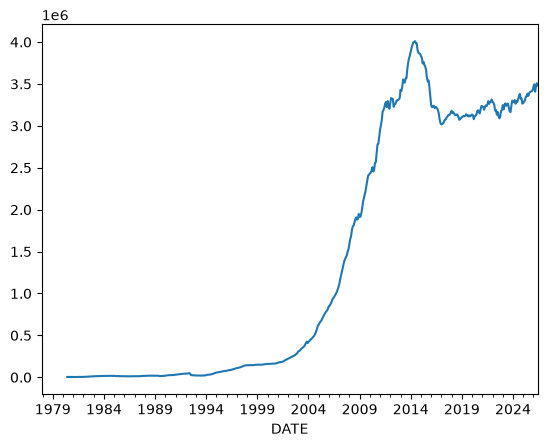

In [47]:
gold_reserves.TRESEGCNM052N.plot.line()

In [48]:
#  CBOE Gold ETF Volatility Index (GVZCLS)
# https://fred.stlouisfed.org/series/GVZCLS
gold_volatility = pdr.DataReader("GVZCLS", "fred", start=start)

<Axes: xlabel='DATE'>

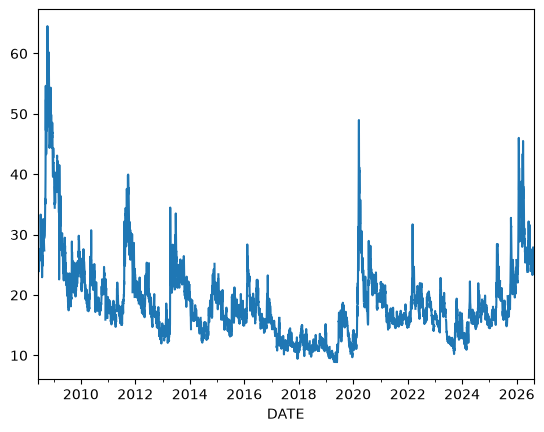

In [49]:
gold_volatility.GVZCLS.plot.line()

In [50]:
#  Crude Oil Prices: West Texas Intermediate (WTI) - Cushing, Oklahoma (DCOILWTICO)
# https://fred.stlouisfed.org/series/DCOILWTICO
oil_wti = pdr.DataReader("DCOILWTICO", "fred", start=start)

<Axes: xlabel='DATE'>

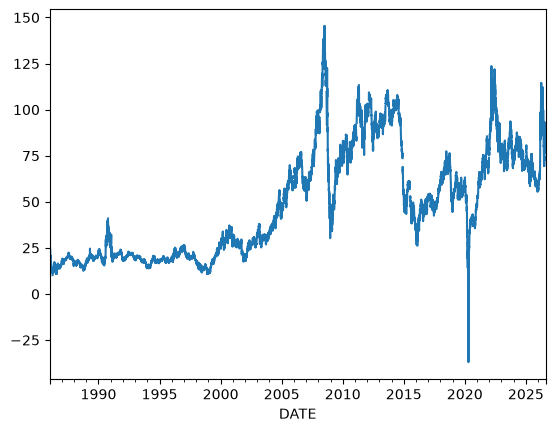

In [51]:
# there is a bug in the data? negative price?
oil_wti.DCOILWTICO.plot.line()

In [52]:
# Crude Oil Prices: Brent - Europe (DCOILBRENTEU)
# https://fred.stlouisfed.org/series/DCOILBRENTEU
oil_brent = pdr.DataReader("DCOILBRENTEU", "fred", start=start)

<Axes: xlabel='DATE'>

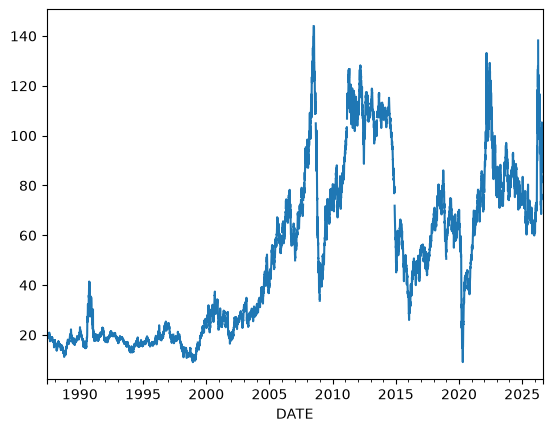

In [53]:
oil_brent.DCOILBRENTEU.plot.line()

In [ ]:
# Web Scraping for Macro
# can't call directly via pd.read_html() as it returns 403 (forbidden) --> need to do a bit of work, but still no Selenium
# https://tradingeconomics.com/united-states/indicators
import requests
from bs4 import BeautifulSoup


url = "https://tradingeconomics.com/united-states/indicators"
headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/58.0.3029.110 Safari/537.3"
}

response = requests.get(url, headers=headers)

# This code scrapes economic indicator data from the Trading Economics website. 
# It sends a request to the URL for United States indicators. 
# The headers mimic a web browser to avoid being blocked. 
# The response object stores the raw HTML of the page. 
# The code does not parse the HTML yet. It just fetches the page content. 
# This is the first step before extracting any data.


In [ ]:

# Check if the request was successful (status code 200)
if response.status_code == 200:
    # Parse the HTML content of the webpage
    soup = BeautifulSoup(response.content, "html.parser")

    # You need to be able to find this table tag and read all behind it
    # Find the div with class "table-responsive"
    table_div = soup.find("div", class_="table-responsive")

    # Extract the table within the div
    table = table_div.find("table")

    # Use pandas to read the table into a DataFrame
    df = pd.read_html(str(table))[0]  # Assuming there's only one table, otherwise, loop through the list

    # Display the DataFrame
    print(df)
else:
    print("Failed to retrieve data from the webpage.")

# This code checks if the webpage download worked. If the status code is 200, it means success. 
# It then parses the HTML using BeautifulSoup. It looks for a div with the class "table-responsive". 
# Inside that div, it finds the table. It converts that table into a pandas DataFrame. 
# It prints the DataFrame. If the status code is not 200, it prints a failure message. 
# The code assumes only one table exists. The data is now in a structured format for analysis.


FileNotFoundError: [Errno 2] No such file or directory: <table class="table table-hover">
<thead align="center" id="ctl00_ContentPlaceHolder1_ctl00_Repeater1_ctl00_Repeater2_ctl00_panelCategoryGroup" valign="middle">
<tr>
<th class="col-md-4 col-xs-5"></th>
<th>Last</th>
<th>Previous</th>
<th class="d-none d-lg-table-cell">Highest</th>
<th class="d-none d-lg-table-cell">Lowest</th>
<th></th>
<th></th>
</tr>
</thead>
<tbody>
<tr>
<td style="padding-left: 10px; text-align: left; font-weight: 600; white-space: normal; min-width: 200px;">
<a href="/united-states/currency">
                                                            Currency
                                                        </a></td>
<td>98.83</td>
<td>98.79</td>
<td class="d-none d-lg-table-cell">165</td>
<td class="d-none d-lg-table-cell">70.7</td>
<td> </td>
<td class="d-none d-sm-table-cell">Aug/26</td>
</tr>
<tr>
<td style="padding-left: 10px; text-align: left; font-weight: 600; white-space: normal; min-width: 

In [56]:
# rEdit attempt to fix
import requests
from bs4 import BeautifulSoup
import pandas as pd

url = "https://tradingeconomics.com/united-states/indicators"
headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/58.0.3029.110 Safari/537.3"
}

response = requests.get(url, headers=headers)

if response.status_code == 200:
    soup = BeautifulSoup(response.content, "html.parser")
    table_div = soup.find("div", class_="table-responsive")
    
    if table_div:
        table = table_div.find("table")
        
        if table:
            # Extract all rows
            rows = table.find_all("tr")
            data = []
            
            for row in rows:
                cells = row.find_all(["th", "td"])
                row_data = [cell.get_text(strip=True) for cell in cells]
                if row_data:  # Skip empty rows
                    data.append(row_data)
            
            # Convert to DataFrame
            if data:
                df = pd.DataFrame(data)
                print(df)
            else:
                print("No data extracted from the table.")
        else:
            print("Table not found inside the div.")
    else:
        print("Table div not found.")
else:
    print("Failed to retrieve data from the webpage.")

                           0       1         2        3       4  \
0                               Last  Previous  Highest  Lowest   
1                   Currency   98.81     98.79      165    70.7   
2               Stock Market    7719      7708     7817     4.4   
3            GDP Growth Rate     1.5       2.1     34.9     -28   
4     GDP Annual Growth Rate     2.1       2.7     13.4    -7.4   
5          Unemployment Rate     4.1       4.2     14.8     2.5   
6          Non Farm Payrolls     -23        20     4631  -20469   
7             Inflation Rate     3.4       3.5     23.7   -15.8   
8         Inflation Rate MoM     0.1      -0.4        2    -1.8   
9              Interest Rate    3.75      3.75       20    0.25   
10          Balance of Trade  -73.26    -77.65     1.95    -133   
11           Current Account    -227      -221     9.96    -438   
12    Current Account to GDP    -3.6        -4      0.2      -6   
13    Government Debt to GDP     123       122      126    31.

In [57]:
df

,0,1,2,3,4,5,6
0,,Last,Previous,Highest,Lowest,,
1,Currency,98.81,98.79,165,70.7,,Aug/26
2,Stock Market,7719,7708,7817,4.4,points,Aug/26
3,GDP Growth Rate,1.5,2.1,34.9,-28,percent,Jun/26
4,GDP Annual Growth Rate,2.1,2.7,13.4,-7.4,percent,Jun/26
5,Unemployment Rate,4.1,4.2,14.8,2.5,percent,Jul/26
6,Non Farm Payrolls,-23,20,4631,-20469,Thousand,Jul/26
7,Inflation Rate,3.4,3.5,23.7,-15.8,percent,Jul/26
8,Inflation Rate MoM,0.1,-0.4,2,-1.8,percent,Jul/26
9,Interest Rate,3.75,3.75,20,0.25,percent,Jul/26


## 2.5) Financial reporting - EDGAR (in Yahoo)

In [ ]:
# let's check for NVDA
nvda =  yf.Ticker('NVDA')

In [ ]:
# yearly financials for the last 4 years
nvda.financials


,2025-01-31,2024-01-31,2023-01-31,2022-01-31
Tax Effect Of Unusual Items,0.0,0.0,-284130000.0,0.0
Tax Rate For Calcs,0.133,0.12,0.21,0.019
Normalized EBITDA,86137000000.0,35583000000.0,7340000000.0,11351000000.0
Total Unusual Items,0.0,0.0,-1353000000.0,0.0
Total Unusual Items Excluding Goodwill,0.0,0.0,-1353000000.0,0.0
Net Income From Continuing Operation Net Minority Interest,72880000000.0,29760000000.0,4368000000.0,9752000000.0
Reconciled Depreciation,1864000000.0,1508000000.0,1544000000.0,1174000000.0
Reconciled Cost Of Revenue,32639000000.0,16621000000.0,11618000000.0,9439000000.0
EBITDA,86137000000.0,35583000000.0,5987000000.0,11351000000.0
EBIT,84273000000.0,34075000000.0,4443000000.0,10177000000.0


In [ ]:
# balance sheet
nvda.balance_sheet

,2025-01-31,2024-01-31,2023-01-31,2022-01-31,2021-01-31
Treasury Shares Number,NaN,NaN,NaN,NaN,13800000000.0
Ordinary Shares Number,24477000000.0,24640000000.0,24661365720.0,25060000000.0,NaN
Share Issued,24477000000.0,24640000000.0,24661365720.0,25060000000.0,NaN
Net Debt,NaN,2429000000.0,7564000000.0,8956000000.0,6116000000.0
Total Debt,10270000000.0,11056000000.0,12031000000.0,11831000000.0,NaN
...,...,...,...,...,...
Allowance For Doubtful Accounts Receivable,NaN,NaN,NaN,NaN,-21000000.0
Gross Accounts Receivable,NaN,NaN,NaN,NaN,2450000000.0
Cash Cash Equivalents And Short Term Investments,43210000000.0,25984000000.0,13296000000.0,21208000000.0,NaN
Other Short Term Investments,34621000000.0,18704000000.0,9907000000.0,19218000000.0,NaN


In [ ]:
# Basic info:
nvda.basic_info

/usr/local/lib/python3.11/dist-packages/yfinance/base.py:302: DeprecationWarning: 'Ticker.basic_info' is deprecated and will be removed in future, Switch to 'Ticker.fast_info'
  warnings.warn("'Ticker.basic_info' is deprecated and will be removed in future, Switch to 'Ticker.fast_info'", DeprecationWarning)


lazy-loading dict with keys = ['currency', 'dayHigh', 'dayLow', 'exchange', 'fiftyDayAverage', 'lastPrice', 'lastVolume', 'marketCap', 'open', 'previousClose', 'quoteType', 'regularMarketPreviousClose', 'shares', 'tenDayAverageVolume', 'threeMonthAverageVolume', 'timezone', 'twoHundredDayAverage', 'yearChange', 'yearHigh', 'yearLow']

In [ ]:
# marketCap is quite useful, but don't know when it was updated? Daily?
nvda.basic_info['marketCap']/1e9

2653.011970569656

In [ ]:
# read this article for full info: https://zoo.cs.yale.edu/classes/cs458/lectures/yfinance.html

## 2.6 Web Scraping - company info for clustering

In [67]:
# This code downloads a CSV file from the CompaniesMarketCap website. 
# It sends a GET request with a browser-like header to avoid being blocked. 
# If the request succeeds, it parses the HTML to find a download link. 
# The link is identified by the "rel" attribute "nofollow" and an "href" containing "?download=csv". 
# It then constructs the full download URL. It sends a second request to download the CSV file. 
# If successful, it saves the file locally as "global_stocks.csv". 
# The code prints success or failure messages at each step. 
# The file contains data about global stock market capitalization. 
# This is a real-world example of web scraping with a download step.


# ask chatGPT: emulate clicking the link and downloading the content
import requests
from bs4 import BeautifulSoup

# URL of the webpage
url = "https://companiesmarketcap.com/"

# Define headers with a user-agent to mimic a web browser
headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/58.0.3029.110 Safari/537.3"
}

# Send a GET request to the URL with headers
response = requests.get(url, headers=headers)

# Check if the request was successful (status code 200)
if response.status_code == 200:
    # Parse the HTML content of the webpage
    soup = BeautifulSoup(response.content, "html.parser")

    # Find the download link within the webpage
    download_link = soup.find("a", {"rel": "nofollow", "href": "?download=csv"})

    # If the download link is found
    if download_link:
        # Extract the href attribute which contains the actual download link
        download_url = 'https://companiesmarketcap.com/'+download_link["href"]

        # Download the CSV file using the obtained download URL
        download_response = requests.get(download_url, headers=headers)

        # Check if the download request was successful
        if download_response.status_code == 200:
            # Save the content of the response to a local file
            with open("global_stocks.csv", "wb") as f:
                f.write(download_response.content)
            print("CSV file downloaded successfully.")
        else:
            print("Failed to download the CSV file.")
    else:
        print("Download link not found on the webpage.")
else:
    print("Failed to retrieve data from the webpage.")

CSV file downloaded successfully.


In [ ]:
global_stocks = pd.read_csv("global_stocks.csv")
# ^ This code loads the CSV file you just downloaded into a pandas DataFrame.

In [68]:
global_stocks['marketcap_b_usd'] = global_stocks.marketcap/1e9
# ^ This code creates a new column called marketcap_b_usd in the global_stocks DataFrame. 
# It takes the existing marketcap column and divides each value by 1e9 (one billion). 
# This converts the market cap from its original unit (likely USD) into billions of USD. 
# The new column makes the numbers easier to read and compare


In [63]:
global_stocks.head(10)

,Rank,Name,Symbol,marketcap,price (USD),country,marketcap_b_usd
0,1,NVIDIA,NVDA,5269520646144,217.5600,United States,5269.520646
1,2,Apple,AAPL,4623874129920,316.8300,United States,4623.874130
2,3,Alphabet (Google),GOOG,4178969100288,341.7000,United States,4178.969100
3,4,Microsoft,MSFT,3596265979904,484.3100,United States,3596.265980
4,5,Amazon,AMZN,2867433570304,265.8400,United States,2867.433570
5,6,TSMC,TSM,2137293979648,412.0900,Taiwan,2137.293980
6,7,SpaceX,SPCX,1839775088640,139.6500,United States,1839.775089
7,8,Broadcom,AVGO,1724527804416,362.4800,United States,1724.527804
8,9,Saudi Aramco,2222.SR,1716404609598,7.0953,Saudi Arabia,1716.404610
9,10,Meta Platforms (Facebook),META,1391014838272,546.0300,United States,1391.014838


In [69]:
global_stocks.info()
# ^ This code prints a summary of the global_stocks DataFrame. 
# It shows the number of entries, column names, data types, and memory usage.

<class 'pandas.DataFrame'>
RangeIndex: 11261 entries, 0 to 11260
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Rank             11261 non-null  int64  
 1   Name             11261 non-null  str    
 2   Symbol           11260 non-null  str    
 3   marketcap        11261 non-null  int64  
 4   price (USD)      11261 non-null  float64
 5   country          11261 non-null  str    
 6   marketcap_b_usd  11261 non-null  float64
dtypes: float64(2), int64(2), str(3)
memory usage: 616.0 KB
